# Production-Grade Churn Classification: XGBoost vs Small LLM

This notebook builds a production-grade XGBoost churn classifier with robust feature engineering,
hyperparameter tuning via Optuna, and compares performance against the fine-tuned SLM from
`04_churn_agent_phi3_finetuning.ipynb`.

## Outputs
- Trained XGBoost model + preprocessing pipeline
- Feature importance analysis
- Hyperparameter tuning history
- Head-to-head comparison: XGBoost vs SLM (accuracy, F1, latency, interpretability)

---
## Phase 1: Environment Setup & Reproducibility

### State-of-the-Art Context

**Why XGBoost for churn?**
Gradient-boosted trees remain the strongest tabular learner for structured customer data.
Unlike LLMs that must serialize features into text, XGBoost operates on native numeric/categorical
representations — capturing nonlinear interactions, handling missing values natively, and providing
built-in feature importance for business stakeholders.

**Comparison rationale:** The SLM approach (notebook 04) serializes customer profiles into text
and predicts `{"risk": "HIGH_RISK"}`. XGBoost provides a traditional ML baseline. Comparing
both reveals whether LLM-based reasoning adds value over engineered features for churn prediction.

In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Notebook started:", datetime.now().isoformat())
print("xgboost:", xgb.__version__)
print("optuna:", optuna.__version__)
print("shap:", shap.__version__)

Notebook started: 2026-05-21T10:51:56.638717
xgboost: 3.2.0
optuna: 4.8.0
shap: 0.51.0


In [2]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed()

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

EXPERIMENT_NAME = "churn_xgboost_production"
ARTIFACT_DIR = PROJECT_ROOT / "experimentation" / "artifacts" / EXPERIMENT_NAME
MODEL_DIR = ARTIFACT_DIR / "model"

for p in [ARTIFACT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "data_path": str(PROJECT_ROOT / "data" / "raw" / "churn" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    "test_size": 0.20,
    "val_size": 0.15,
    "optuna_n_trials": 80,
    "optuna_cv_folds": 5,
    "xgb_early_stopping_rounds": 30,
    "slm_experiment_summary": str(
        PROJECT_ROOT / "experimentation" / "artifacts" / "churn_llm_production" / "experiment_summary.json"
    ),
}

print("Project root:", PROJECT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)
for k, v in CONFIG.items():
    print(f"  {k:30s}: {v}")

Project root: /Users/jatinder.singh/drive/ai_mkt
Artifact dir: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/churn_xgboost_production
  data_path                     : /Users/jatinder.singh/drive/ai_mkt/data/raw/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
  test_size                     : 0.2
  val_size                      : 0.15
  optuna_n_trials               : 80
  optuna_cv_folds               : 5
  xgb_early_stopping_rounds     : 30
  slm_experiment_summary        : /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/churn_llm_production/experiment_summary.json


---
## Phase 2: Data Loading & Quality Audit

In [3]:
data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(data_path)

df_raw = pd.read_csv(data_path)
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
print("\nDtypes:")
print(df_raw.dtypes.to_string())
print("\nMissing values:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0].to_string())
print("\nChurn distribution:")
print(df_raw["Churn"].value_counts().to_string())
print(f"Churn rate: {df_raw['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

Missing values:
Series([], )

Churn distribution:
C

In [4]:
# TotalCharges has whitespace strings where tenure=0
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_missing_tc = df["TotalCharges"].isna().sum()
print(f"TotalCharges missing after coerce: {n_missing_tc}")
print("These rows have tenure=0:")
print(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head())

# Fill: tenure=0 means brand new, total charges = monthly charges (first month)
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

# Binary target
df["target"] = (df["Churn"] == "Yes").astype(int)

# Drop customerID (no predictive value)
df = df.drop(columns=["customerID", "Churn"])
print(f"\nCleaned shape: {df.shape}")
print(f"Target: 0={df['target'].value_counts()[0]}, 1={df['target'].value_counts()[1]}")

TotalCharges missing after coerce: 11
These rows have tenure=0:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN

Cleaned shape: (7043, 20)
Target: 0=5174, 1=1869


---
## Phase 3: Production-Grade Feature Engineering

We engineer features that capture domain knowledge about churn drivers:
- **Tenure-charge interactions**: spending velocity and lifetime value proxies
- **Service complexity**: total service count, protection bundle indicators
- **Contract risk encoding**: ordinal encoding of commitment level
- **Payment risk signals**: electronic check is a known churn driver

In [5]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build production features from raw telecom data."""
    out = df.copy()

    # --- Tenure-charge interactions ---
    out["AvgChargesPerMonth"] = out["TotalCharges"] / out["tenure"].clip(lower=1)
    out["ChargeGrowthRate"] = (out["MonthlyCharges"] - out["AvgChargesPerMonth"]) / out[
        "AvgChargesPerMonth"
    ].clip(lower=0.01)
    out["TenureMonthlyInteraction"] = out["tenure"] * out["MonthlyCharges"]
    out["TenureBin"] = pd.cut(
        out["tenure"],
        bins=[-1, 6, 12, 24, 48, 72, 999],
        labels=[0, 1, 2, 3, 4, 5],
    ).astype(int)

    # --- Service complexity ---
    service_cols = [
        "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    ]
    out["ServiceCount"] = sum(
        (out[c].isin(["Yes", "Yes, but no internet"])).astype(int) for c in service_cols
    )

    protection_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    out["ProtectionCount"] = sum((out[c] == "Yes").astype(int) for c in protection_cols)
    out["HasProtectionBundle"] = (out["ProtectionCount"] >= 3).astype(int)

    streaming_cols = ["StreamingTV", "StreamingMovies"]
    out["StreamingCount"] = sum((out[c] == "Yes").astype(int) for c in streaming_cols)

    out["CostPerService"] = out["MonthlyCharges"] / out["ServiceCount"].clip(lower=1)

    # --- Contract risk ---
    contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    out["ContractRisk"] = out["Contract"].map(contract_map).fillna(0).astype(int)

    # --- Payment risk ---
    out["IsElectronicCheck"] = (out["PaymentMethod"] == "Electronic check").astype(int)
    out["IsAutoPayment"] = out["PaymentMethod"].str.contains("automatic", case=False, na=False).astype(int)

    # --- Tenure-contract interaction ---
    out["ShortTenureMonthly"] = ((out["tenure"] <= 12) & (out["ContractRisk"] == 0)).astype(int)

    # --- Internet service risk ---
    out["IsFiberOptic"] = (out["InternetService"] == "Fiber optic").astype(int)
    out["FiberNoProtection"] = ((out["IsFiberOptic"] == 1) & (out["ProtectionCount"] == 0)).astype(int)

    # --- Demographics ---
    out["HasPartnerOrDependents"] = ((out["Partner"] == "Yes") | (out["Dependents"] == "Yes")).astype(int)
    out["SeniorAlone"] = ((out["SeniorCitizen"] == 1) & (out["HasPartnerOrDependents"] == 0)).astype(int)

    return out


df = engineer_features(df)
print(f"Shape after feature engineering: {df.shape}")
new_cols = [
    "AvgChargesPerMonth", "ChargeGrowthRate", "TenureMonthlyInteraction", "TenureBin",
    "ServiceCount", "ProtectionCount", "HasProtectionBundle", "StreamingCount",
    "CostPerService", "ContractRisk", "IsElectronicCheck", "IsAutoPayment",
    "ShortTenureMonthly", "IsFiberOptic", "FiberNoProtection",
    "HasPartnerOrDependents", "SeniorAlone",
]
print(f"Engineered features ({len(new_cols)}): {new_cols}")

Shape after feature engineering: (7043, 37)
Engineered features (17): ['AvgChargesPerMonth', 'ChargeGrowthRate', 'TenureMonthlyInteraction', 'TenureBin', 'ServiceCount', 'ProtectionCount', 'HasProtectionBundle', 'StreamingCount', 'CostPerService', 'ContractRisk', 'IsElectronicCheck', 'IsAutoPayment', 'ShortTenureMonthly', 'IsFiberOptic', 'FiberNoProtection', 'HasPartnerOrDependents', 'SeniorAlone']


In [6]:
# Encode remaining categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"\nFinal feature matrix shape: {df.shape}")
print(f"All dtypes numeric: {df.select_dtypes(include='object').shape[1] == 0}")

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final feature matrix shape: (7043, 37)
All dtypes numeric: True


In [7]:
y = df["target"]
X = df.drop(columns=["target"])

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

# Stratified split: train → temp → val + test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CONFIG["test_size"], random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=CONFIG["val_size"] / (1 - CONFIG["test_size"]),
    random_state=SEED,
    stratify=y_train_full,
)

print(f"\nTrain: {X_train.shape[0]:,} ({y_train.mean():.1%} churn)")
print(f"Val:   {X_val.shape[0]:,} ({y_val.mean():.1%} churn)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean():.1%} churn)")

# Scale continuous features (fit on train only)
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgChargesPerMonth",
                   "ChargeGrowthRate", "TenureMonthlyInteraction", "CostPerService"]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"\nScaled {len(continuous_cols)} continuous features (fit on train only)")

Features (36): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth', 'ChargeGrowthRate', 'TenureMonthlyInteraction', 'TenureBin', 'ServiceCount', 'ProtectionCount', 'HasProtectionBundle', 'StreamingCount', 'CostPerService', 'ContractRisk', 'IsElectronicCheck', 'IsAutoPayment', 'ShortTenureMonthly', 'IsFiberOptic', 'FiberNoProtection', 'HasPartnerOrDependents', 'SeniorAlone']

Train: 4,577 (26.5% churn)
Val:   1,057 (26.5% churn)
Test:  1,409 (26.5% churn)

Scaled 7 continuous features (fit on train only)


---
## Phase 4: Hyperparameter Tuning with Optuna

We use Optuna's TPE sampler with 5-fold stratified cross-validation.
The objective maximizes ROC-AUC, and `scale_pos_weight` handles class imbalance.

In [8]:
set_seed()

scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": SEED,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

    cv = StratifiedKFold(n_splits=CONFIG["optuna_cv_folds"], shuffle=True, random_state=SEED)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        Xf_train, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf_train, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            Xf_train, yf_train,
            eval_set=[(Xf_val, yf_val)],
            verbose=False,
        )
        y_prob = model.predict_proba(Xf_val)[:, 1]
        scores.append(roc_auc_score(yf_val, y_prob))

    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))

t0 = time.time()
study.optimize(objective, n_trials=CONFIG["optuna_n_trials"], show_progress_bar=True)
tuning_minutes = (time.time() - t0) / 60.0

print(f"\nTuning completed in {tuning_minutes:.1f} minutes")
print(f"Best CV ROC-AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")

scale_pos_weight: 2.77


  0%|          | 0/80 [00:00<?, ?it/s]


Tuning completed in 9.0 minutes
Best CV ROC-AUC: 0.8481
Best params:
  n_estimators          : 119
  max_depth             : 3
  learning_rate         : 0.03782504346254381
  subsample             : 0.7438578170204345
  colsample_bytree      : 0.5379463231889187
  min_child_weight      : 2
  gamma                 : 2.0255259033918485
  reg_alpha             : 0.15145425312092817
  reg_lambda            : 0.006527620890729244


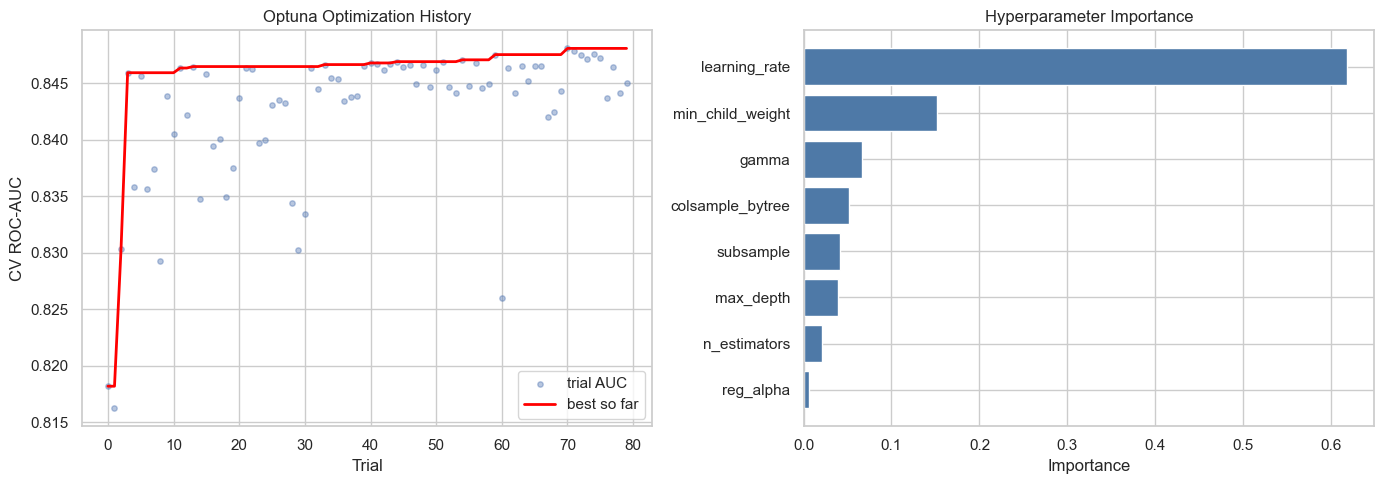

In [9]:
# Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials = study.trials
trial_vals = [t.value for t in trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_vals)
axes[0].scatter(range(len(trial_vals)), trial_vals, alpha=0.4, s=15, label="trial AUC")
axes[0].plot(best_so_far, color="red", linewidth=2, label="best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV ROC-AUC")
axes[0].set_title("Optuna Optimization History")
axes[0].legend()

# Parameter importance (top params)
importance = optuna.importance.get_param_importances(study)
params_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:8]
axes[1].barh([p[0] for p in params_sorted], [p[1] for p in params_sorted], color="#4E79A7")
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 5: Train Final Model & Evaluate

In [12]:
best_params = study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": SEED,
    "scale_pos_weight": scale_pos_weight,
    "early_stopping_rounds": CONFIG["xgb_early_stopping_rounds"],
})

final_model = xgb.XGBClassifier(**best_params)

t0 = time.time()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
train_time = time.time() - t0

print(f"Final model trained in {train_time:.1f}s")
print(f"Best iteration: {final_model.best_iteration}")
print(f"Trees used: {final_model.best_iteration} / {best_params['n_estimators']}")

Final model trained in 1.7s
Best iteration: 107
Trees used: 107 / 119


In [13]:
# Evaluate on held-out test set
t0 = time.time()
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]
inference_time = (time.time() - t0) * 1000  # total ms for test set

acc = accuracy_score(y_test, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

xgb_metrics = {
    "accuracy": float(acc),
    "precision_macro": float(p),
    "recall_macro": float(r),
    "f1_macro": float(f1),
    "precision_weighted": float(p_w),
    "recall_weighted": float(r_w),
    "f1_weighted": float(f1_w),
    "roc_auc": float(auc),
    "average_precision": float(ap),
    "latency_ms_total": float(inference_time),
    "latency_ms_per_sample": float(inference_time / len(X_test)),
    "test_samples": len(X_test),
}

print("Test Set Metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k:24s}: {v:.4f}" if isinstance(v, float) else f"  {k:24s}: {v}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["LOW_RISK", "HIGH_RISK"], zero_division=0))

Test Set Metrics:
  accuracy                : 0.7402
  precision_macro         : 0.7062
  recall_macro            : 0.7566
  f1_macro                : 0.7106
  precision_weighted      : 0.7997
  recall_weighted         : 0.7402
  f1_weighted             : 0.7540
  roc_auc                 : 0.8460
  average_precision       : 0.6613
  latency_ms_total        : 48.4269
  latency_ms_per_sample   : 0.0344
  test_samples            : 1409

Classification Report:
              precision    recall  f1-score   support

    LOW_RISK       0.91      0.72      0.80      1035
   HIGH_RISK       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



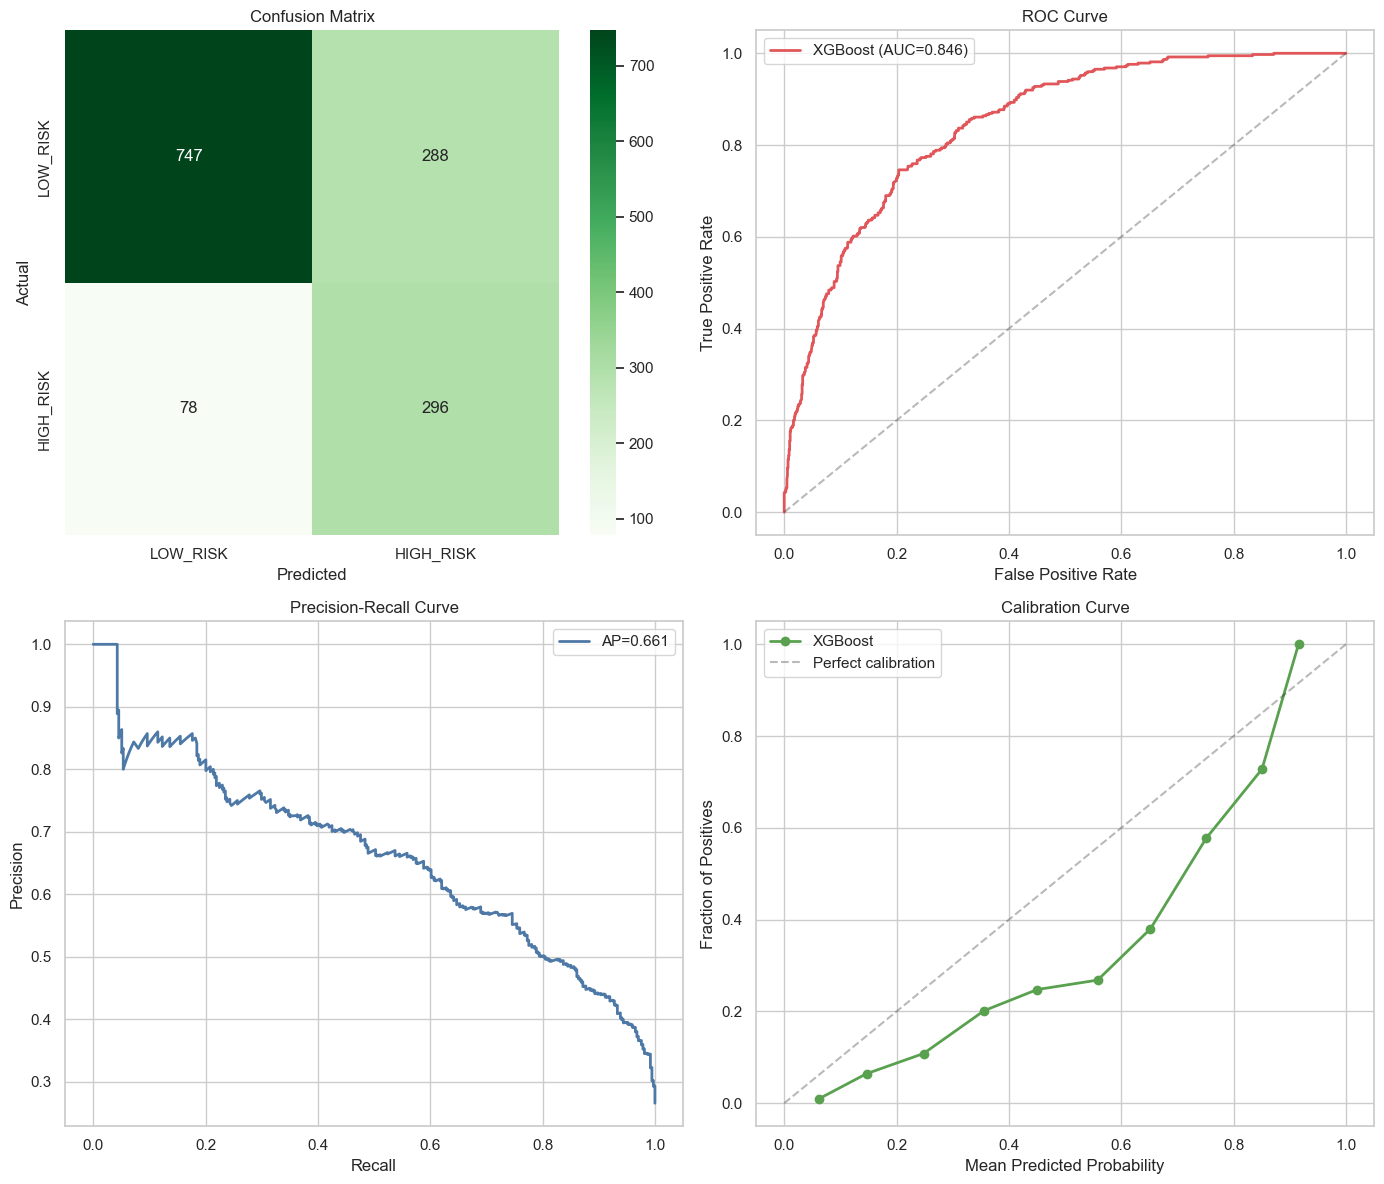

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["LOW_RISK", "HIGH_RISK"],
            yticklabels=["LOW_RISK", "HIGH_RISK"], ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0, 1].plot(fpr, tpr, color="#E15759", linewidth=2, label=f"XGBoost (AUC={auc:.3f})")
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend()

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
axes[1, 0].plot(rec_curve, prec_curve, color="#4E79A7", linewidth=2, label=f"AP={ap:.3f}")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curve")
axes[1, 0].legend()

# 4. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
axes[1, 1].plot(prob_pred, prob_true, "o-", color="#59A14F", linewidth=2, label="XGBoost")
axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")
axes[1, 1].set_xlabel("Mean Predicted Probability")
axes[1, 1].set_ylabel("Fraction of Positives")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

Top 15 Features (by gain):
           feature  importance
      ContractRisk    0.152384
          Contract    0.148911
       TechSupport    0.081705
    OnlineSecurity    0.079977
      IsFiberOptic    0.053595
ShortTenureMonthly    0.039531
 IsElectronicCheck    0.038741
         TenureBin    0.034729
   InternetService    0.029861
            tenure    0.027591
   StreamingMovies    0.021524
    StreamingCount    0.019922
    MonthlyCharges    0.017491
 FiberNoProtection    0.016999
  PaperlessBilling    0.016608


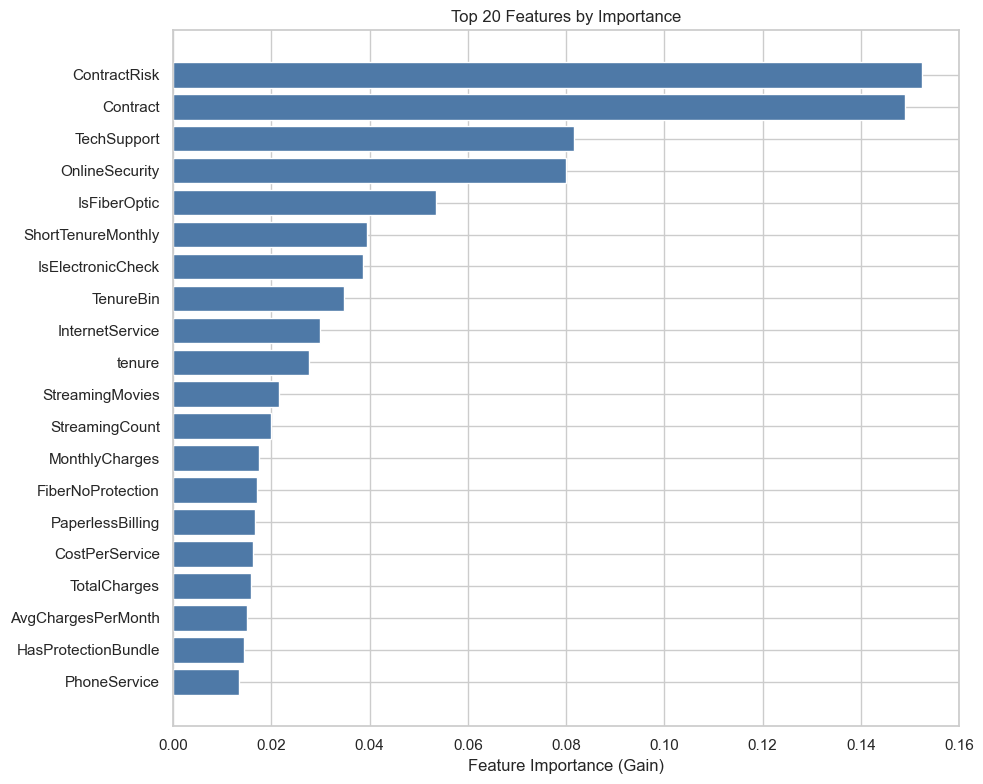

In [15]:
# Feature importance (gain-based)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 15 Features (by gain):")
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(importance_df))
top = importance_df.head(top_n)
ax.barh(top["feature"], top["importance"], color="#4E79A7")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title(f"Top {top_n} Features by Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

### SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded feature attribution
based on cooperative game theory. Unlike gain-based importance which measures split utility,
SHAP values quantify each feature's marginal contribution to individual predictions — enabling
both global interpretability (which features matter overall) and local explanations (why this
specific customer was flagged HIGH_RISK).

This is a key advantage of XGBoost over the SLM approach: transparent, auditable explanations
that business stakeholders can act on directly.

SHAP values shape: (1409, 36)
Test samples: 1409, Features: 36


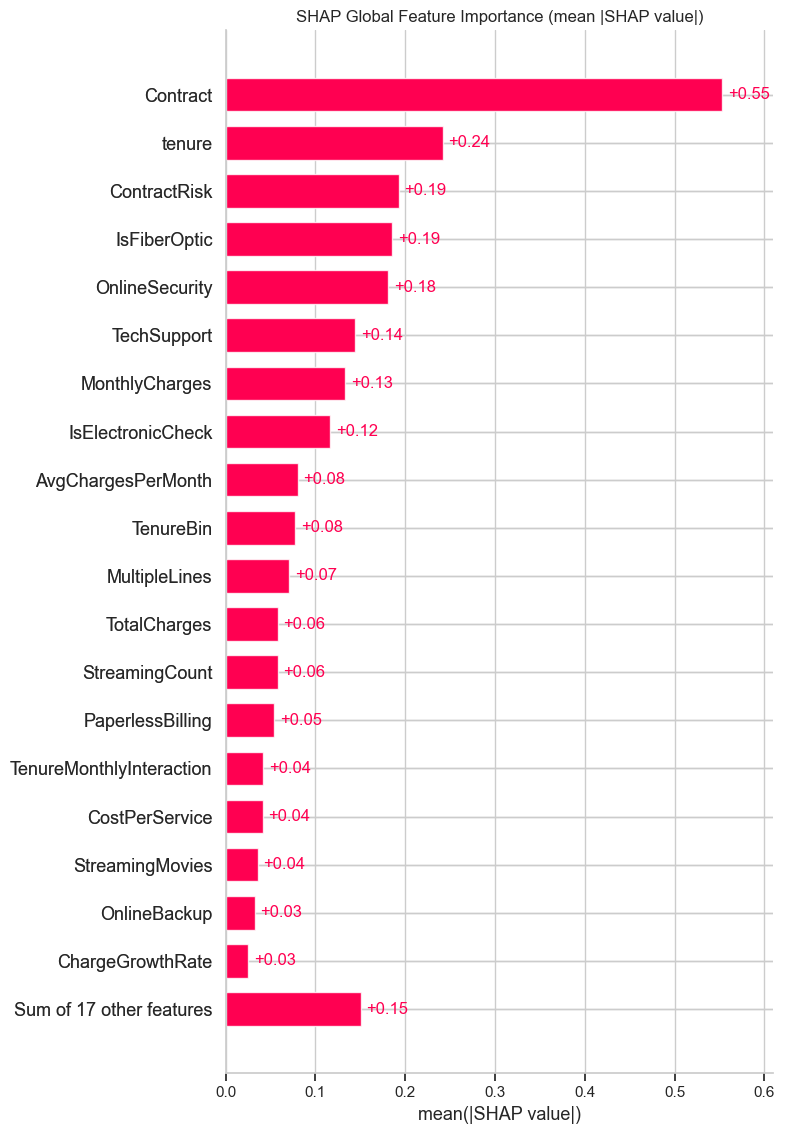

In [16]:
# Compute SHAP values using TreeExplainer (exact, fast for tree models)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Test samples: {X_test.shape[0]}, Features: {X_test.shape[1]}")

# --- 1. Global Feature Importance (mean |SHAP|) ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title("SHAP Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

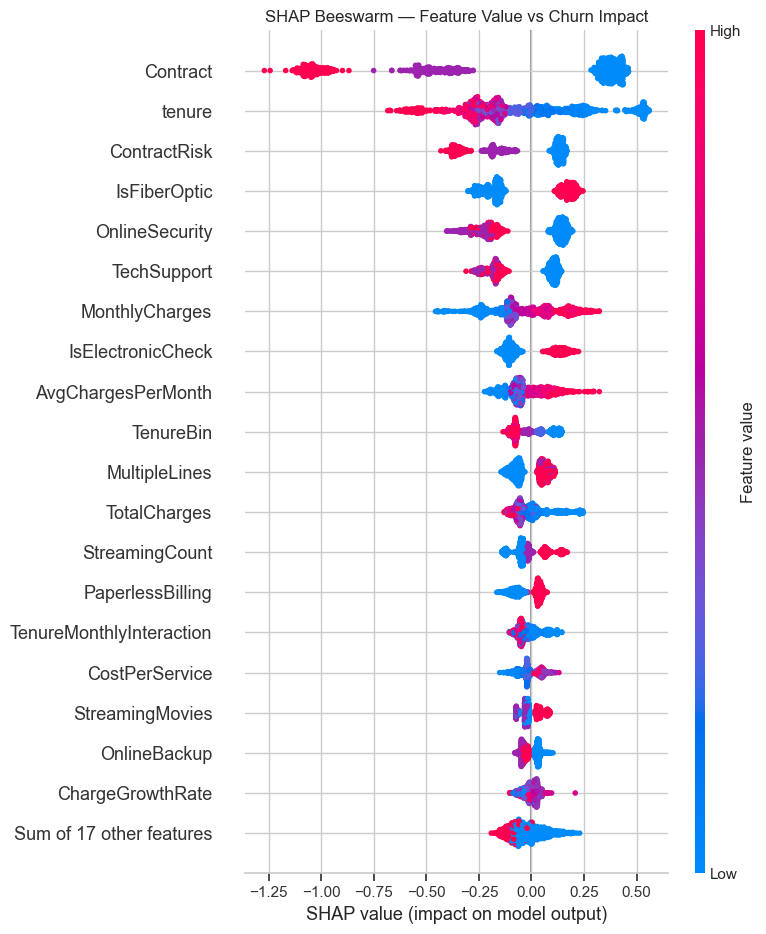

In [17]:
# --- 2. Beeswarm: feature value vs SHAP impact ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm — Feature Value vs Churn Impact")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

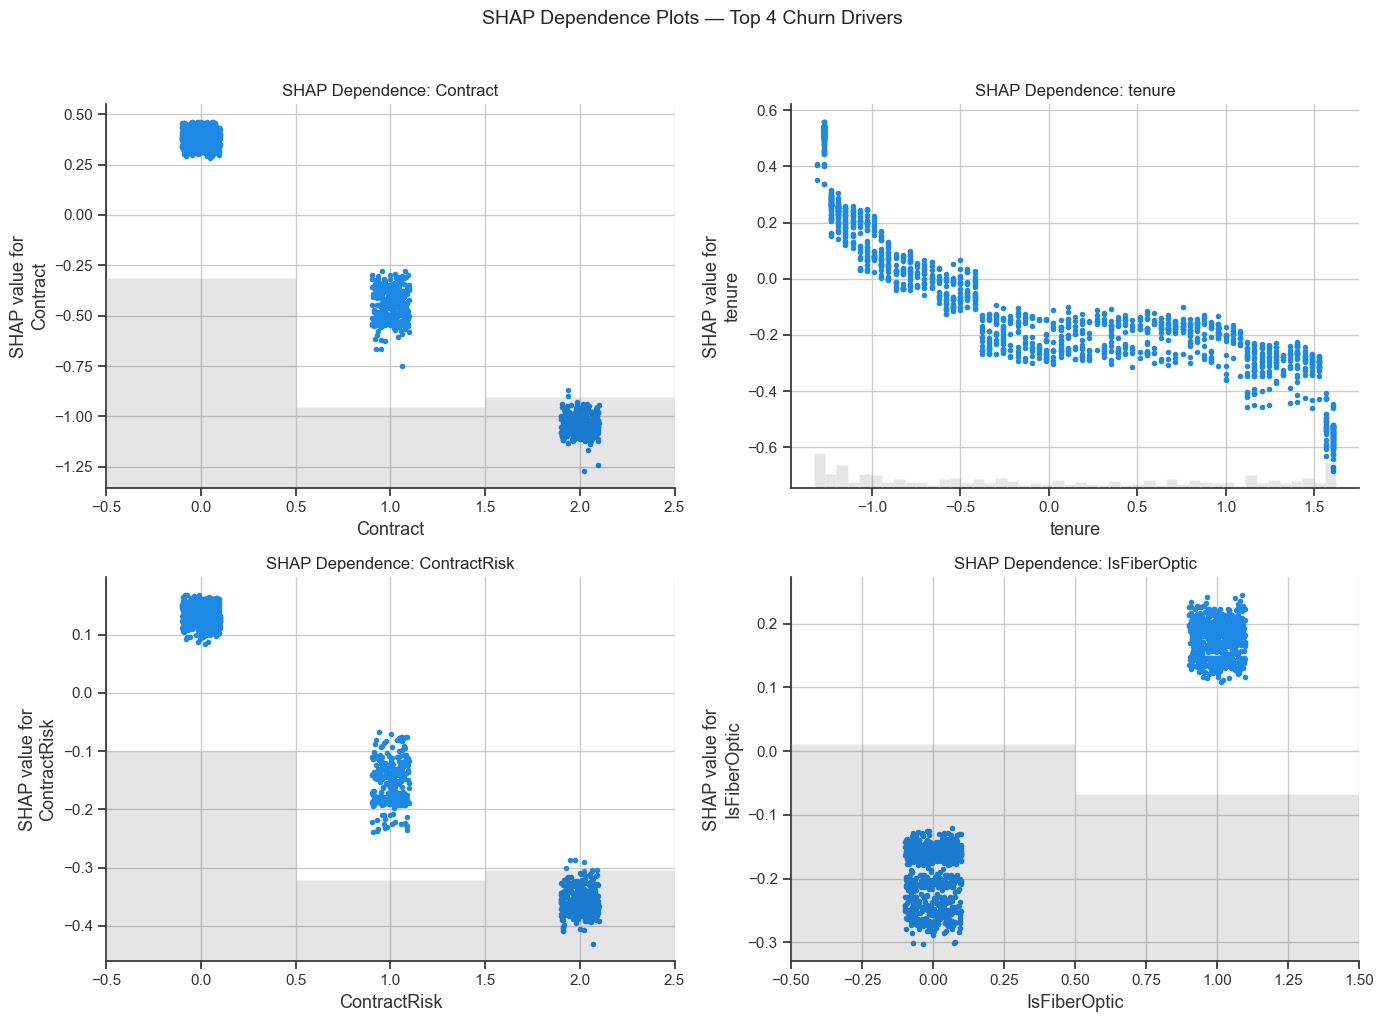

Top 4 features by mean |SHAP|:
  Contract                      : mean|SHAP| = 0.5531
  tenure                        : mean|SHAP| = 0.2416
  ContractRisk                  : mean|SHAP| = 0.1925
  IsFiberOptic                  : mean|SHAP| = 0.1853


In [18]:
# --- 3. Dependence plots for top churn drivers ---
# Identify top 4 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_4_idx = np.argsort(mean_abs_shap)[-4:][::-1]
top_4_features = [feature_names[i] for i in top_4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_4_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(f"SHAP Dependence: {feat}")

plt.suptitle("SHAP Dependence Plots — Top 4 Churn Drivers", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "shap_dependence_top4.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 4 features by mean |SHAP|:")
for feat in top_4_features:
    idx = feature_names.index(feat)
    print(f"  {feat:30s}: mean|SHAP| = {mean_abs_shap[idx]:.4f}")

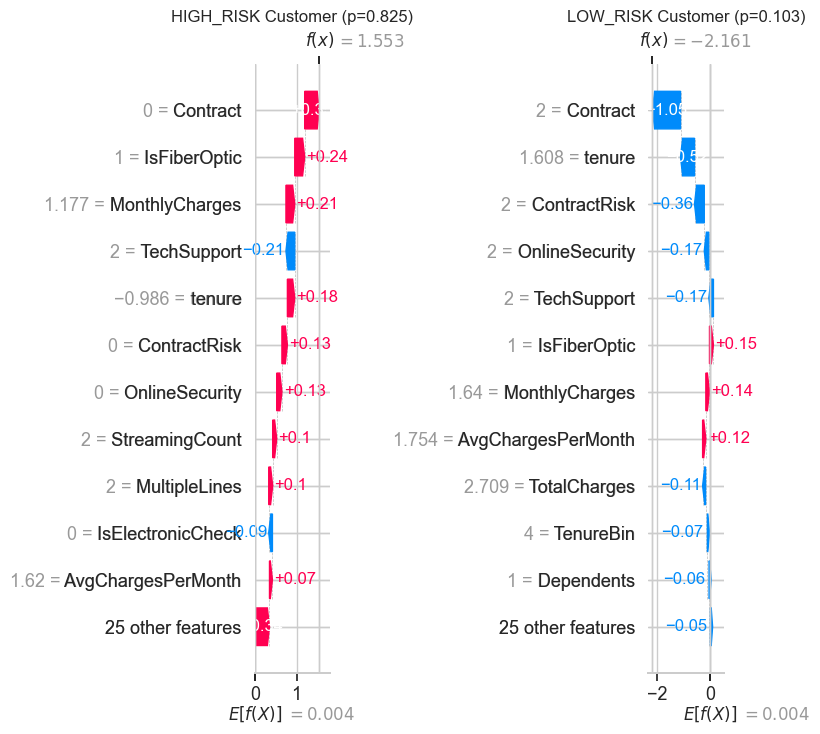

HIGH_RISK example (index 1): actual=LOW_RISK, pred=HIGH_RISK, p=0.825
LOW_RISK example (index 0): actual=LOW_RISK, pred=LOW_RISK, p=0.103


In [19]:
# --- 4. Local explanations: waterfall plots for individual customers ---
# Pick a HIGH_RISK and LOW_RISK prediction from the test set
high_risk_idx = np.where(y_pred == 1)[0]
low_risk_idx = np.where(y_pred == 0)[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# HIGH_RISK example
hr_i = high_risk_idx[0]
plt.sca(axes[0])
shap.plots.waterfall(shap_values[hr_i], max_display=12, show=False)
axes[0].set_title(f"HIGH_RISK Customer (p={y_prob[hr_i]:.3f})")

# LOW_RISK example
lr_i = low_risk_idx[0]
plt.sca(axes[1])
shap.plots.waterfall(shap_values[lr_i], max_display=12, show=False)
axes[1].set_title(f"LOW_RISK Customer (p={y_prob[lr_i]:.3f})")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "shap_waterfall_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"HIGH_RISK example (index {hr_i}): actual={'HIGH_RISK' if y_test.iloc[hr_i] == 1 else 'LOW_RISK'}, "
      f"pred=HIGH_RISK, p={y_prob[hr_i]:.3f}")
print(f"LOW_RISK example (index {lr_i}): actual={'HIGH_RISK' if y_test.iloc[lr_i] == 1 else 'LOW_RISK'}, "
      f"pred=LOW_RISK, p={y_prob[lr_i]:.3f}")

Feature Group Contributions (SHAP):
     Feature Group  Mean Total |SHAP|
Contract & Payment           0.943042
          Services           0.781511
  Tenure & Charges           0.698422
      Demographics           0.047533


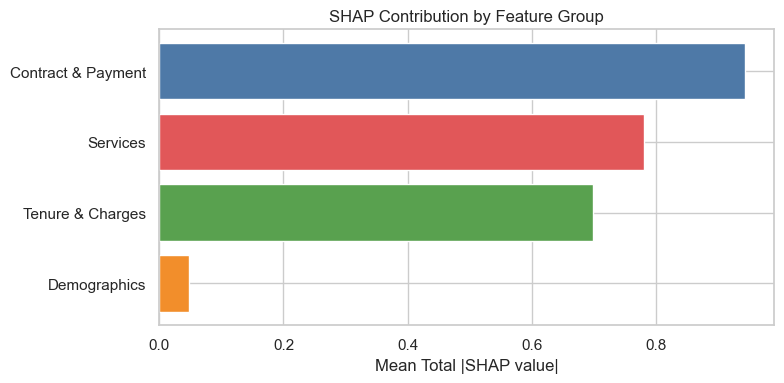


Saved SHAP summary to /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/churn_xgboost_production/shap_summary.json


In [20]:
# --- 5. SHAP feature cohort analysis ---
# Group features by category and show aggregate SHAP contribution
feature_groups = {
    "Tenure & Charges": ["tenure", "MonthlyCharges", "TotalCharges", "AvgChargesPerMonth",
                         "ChargeGrowthRate", "TenureMonthlyInteraction", "TenureBin", "CostPerService"],
    "Contract & Payment": ["Contract", "ContractRisk", "PaymentMethod", "IsElectronicCheck",
                           "IsAutoPayment", "PaperlessBilling", "ShortTenureMonthly"],
    "Services": ["ServiceCount", "ProtectionCount", "HasProtectionBundle", "StreamingCount",
                 "InternetService", "IsFiberOptic", "FiberNoProtection",
                 "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                 "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"],
    "Demographics": ["gender", "SeniorCitizen", "Partner", "Dependents",
                     "HasPartnerOrDependents", "SeniorAlone"],
}

group_importance = {}
for group, features in feature_groups.items():
    valid = [f for f in features if f in feature_names]
    if valid:
        idxs = [feature_names.index(f) for f in valid]
        group_importance[group] = float(np.abs(shap_values.values[:, idxs]).sum(axis=1).mean())

group_df = pd.DataFrame(
    sorted(group_importance.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature Group", "Mean Total |SHAP|"],
)

print("Feature Group Contributions (SHAP):")
print(group_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4E79A7", "#E15759", "#59A14F", "#F28E2B"]
ax.barh(group_df["Feature Group"], group_df["Mean Total |SHAP|"], color=colors[:len(group_df)])
ax.set_xlabel("Mean Total |SHAP value|")
ax.set_title("SHAP Contribution by Feature Group")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "shap_feature_groups.png", dpi=150, bbox_inches="tight")
plt.show()

# Save SHAP summary
shap_summary = {
    "top_features": {feat: float(mean_abs_shap[feature_names.index(feat)])
                     for feat in top_4_features},
    "feature_group_importance": group_importance,
}
with open(ARTIFACT_DIR / "shap_summary.json", "w") as f:
    json.dump(shap_summary, f, indent=2)
print("\nSaved SHAP summary to", ARTIFACT_DIR / "shap_summary.json")

---
## Phase 6: XGBoost vs SLM Head-to-Head Comparison

We load the SLM experiment results from notebook 04 and produce a side-by-side comparison
covering accuracy, F1, latency, and practical tradeoffs.

In [21]:
slm_summary_path = Path(CONFIG["slm_experiment_summary"])
slm_metrics = None

if slm_summary_path.exists():
    with open(slm_summary_path) as f:
        slm_summary = json.load(f)
    slm_metrics = slm_summary.get("after_metrics", {})
    slm_baseline = slm_summary.get("baseline_metrics", {})
    print("SLM experiment summary loaded.")
    print(f"  Model: {slm_summary.get('model_ref', 'unknown')}")
    print(f"  Train time: {slm_summary.get('train_time_minutes', 0):.1f} min")
    print(f"  Forgetting rate: {slm_summary.get('forgetting_rate', 0):.2%}")
    print("\n  SLM after-tuning metrics:")
    for k, v in slm_metrics.items():
        print(f"    {k:22s}: {v:.4f}")
else:
    print(f"SLM summary not found at {slm_summary_path}")
    print("Using placeholder metrics — run notebook 04 first for real comparison.")
    slm_metrics = {
        "accuracy": 0.50,
        "precision_macro": 0.50,
        "recall_macro": 0.50,
        "f1_macro": 0.50,
        "schema_valid_rate": 0.0,
        "unknown_rate": 1.0,
        "latency_ms_mean": 500.0,
        "latency_ms_p95": 800.0,
    }
    slm_baseline = slm_metrics.copy()

SLM experiment summary loaded.
  Model: /Users/jatinder.singh/drive/ai_mkt/models/qwen2.5-0.5b-instruct-q5_0.gguf
  Train time: 62.2 min
  Forgetting rate: 14.71%

  SLM after-tuning metrics:
    accuracy              : 0.7914
    precision_macro       : 0.7187
    recall_macro          : 0.6809
    f1_macro              : 0.6947
    schema_valid_rate     : 1.0000
    unknown_rate          : 0.0000
    latency_ms_mean       : 397.9738
    latency_ms_p95        : 677.3697


In [22]:
# Build comparison table
comparison_data = {
    "Metric": [
        "Accuracy",
        "Precision (macro)",
        "Recall (macro)",
        "F1 (macro)",
        "ROC-AUC",
        "Latency (ms/sample)",
        "Schema Valid Rate",
        "Training Time (min)",
    ],
    "XGBoost": [
        xgb_metrics["accuracy"],
        xgb_metrics["precision_macro"],
        xgb_metrics["recall_macro"],
        xgb_metrics["f1_macro"],
        xgb_metrics["roc_auc"],
        xgb_metrics["latency_ms_per_sample"],
        1.0,  # XGBoost always produces valid output
        train_time / 60.0,
    ],
    "SLM (Fine-tuned)": [
        slm_metrics.get("accuracy", 0),
        slm_metrics.get("precision_macro", 0),
        slm_metrics.get("recall_macro", 0),
        slm_metrics.get("f1_macro", 0),
        None,  # SLM doesn't produce probability scores
        slm_metrics.get("latency_ms_mean", 0),
        slm_metrics.get("schema_valid_rate", 0),
        slm_summary.get("train_time_minutes", 0) if slm_summary_path.exists() else 0,
    ],
    "SLM (Baseline)": [
        slm_baseline.get("accuracy", 0),
        slm_baseline.get("precision_macro", 0),
        slm_baseline.get("recall_macro", 0),
        slm_baseline.get("f1_macro", 0),
        None,
        slm_baseline.get("latency_ms_mean", 0),
        slm_baseline.get("schema_valid_rate", 0),
        0,
    ],
}

comp_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("HEAD-TO-HEAD: XGBoost vs Small LLM (Churn Prediction)")
print("=" * 80)
print(comp_df.to_string(index=False, float_format=lambda v: f"{v:.4f}" if v is not None else "N/A"))
print()

# Highlight winner per metric
for _, row in comp_df.iterrows():
    metric = row["Metric"]
    xgb_val = row["XGBoost"]
    slm_val = row["SLM (Fine-tuned)"]
    if xgb_val is None or slm_val is None:
        continue
    if metric == "Latency (ms/sample)":
        winner = "XGBoost" if xgb_val < slm_val else "SLM"
    else:
        winner = "XGBoost" if xgb_val > slm_val else "SLM"
    print(f"  {metric:25s} → Winner: {winner}")

HEAD-TO-HEAD: XGBoost vs Small LLM (Churn Prediction)
             Metric  XGBoost  SLM (Fine-tuned)  SLM (Baseline)
           Accuracy   0.7402            0.7914          0.7727
  Precision (macro)   0.7062            0.7187          0.3864
     Recall (macro)   0.7566            0.6809          0.5000
         F1 (macro)   0.7106            0.6947          0.4359
            ROC-AUC   0.8460               NaN             NaN
Latency (ms/sample)   0.0344          397.9738        590.9618
  Schema Valid Rate   1.0000            1.0000          0.0000
Training Time (min)   0.0287           62.1963          0.0000

  Accuracy                  → Winner: SLM
  Precision (macro)         → Winner: SLM
  Recall (macro)            → Winner: XGBoost
  F1 (macro)                → Winner: XGBoost
  ROC-AUC                   → Winner: SLM
  Latency (ms/sample)       → Winner: XGBoost
  Schema Valid Rate         → Winner: SLM
  Training Time (min)       → Winner: SLM


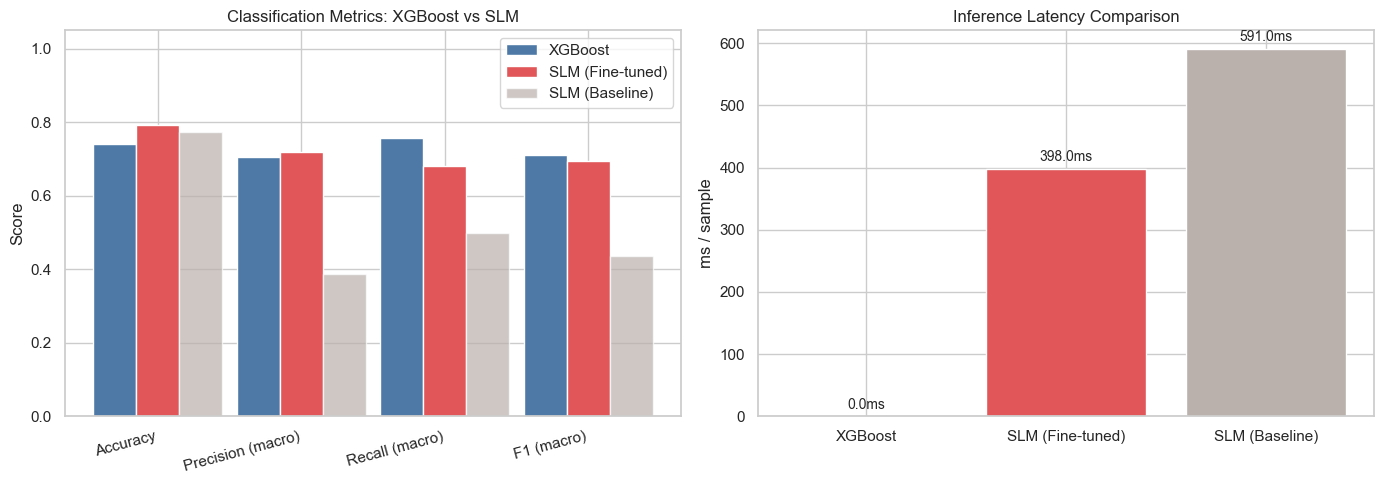

In [23]:
# Visual comparison
compare_metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
comp_subset = comp_df[comp_df["Metric"].isin(compare_metrics)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(compare_metrics))
width = 0.3
axes[0].bar(x - width, comp_subset["XGBoost"], width, label="XGBoost", color="#4E79A7")
axes[0].bar(x, comp_subset["SLM (Fine-tuned)"], width, label="SLM (Fine-tuned)", color="#E15759")
axes[0].bar(x + width, comp_subset["SLM (Baseline)"], width, label="SLM (Baseline)", color="#BAB0AC", alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare_metrics, rotation=15, ha="right")
axes[0].set_ylabel("Score")
axes[0].set_title("Classification Metrics: XGBoost vs SLM")
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Latency comparison
latencies = {
    "XGBoost": xgb_metrics["latency_ms_per_sample"],
    "SLM (Fine-tuned)": slm_metrics.get("latency_ms_mean", 0),
    "SLM (Baseline)": slm_baseline.get("latency_ms_mean", 0),
}
colors = ["#4E79A7", "#E15759", "#BAB0AC"]
axes[1].bar(latencies.keys(), latencies.values(), color=colors)
axes[1].set_ylabel("ms / sample")
axes[1].set_title("Inference Latency Comparison")
for i, (k, v) in enumerate(latencies.items()):
    axes[1].text(i, v + max(latencies.values()) * 0.02, f"{v:.1f}ms", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "xgboost_vs_slm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
print("=" * 80)
print("ANALYSIS: XGBoost vs Small LLM for Churn Prediction")
print("=" * 80)

xgb_f1 = xgb_metrics["f1_macro"]
slm_f1 = slm_metrics.get("f1_macro", 0)
xgb_lat = xgb_metrics["latency_ms_per_sample"]
slm_lat = slm_metrics.get("latency_ms_mean", 1)

print(f"""
1. ACCURACY & F1:
   XGBoost F1 (macro): {xgb_f1:.4f}
   SLM F1 (macro):     {slm_f1:.4f}
   Delta:              {xgb_f1 - slm_f1:+.4f}

2. LATENCY:
   XGBoost: {xgb_lat:.2f} ms/sample
   SLM:     {slm_lat:.2f} ms/sample
   Speedup: {slm_lat / max(xgb_lat, 0.001):.0f}x faster (XGBoost)

3. ROC-AUC (XGBoost only): {xgb_metrics['roc_auc']:.4f}
   SLM produces binary labels, not calibrated probabilities.
   XGBoost provides risk scores for threshold optimization.

4. INTERPRETABILITY:
   XGBoost: Built-in feature importance, SHAP-ready.
   SLM: Black-box; requires prompt engineering for explanations.

5. PRODUCTION TRADEOFFS:
   XGBoost: Sub-millisecond inference, small model footprint (~1 MB),
            calibrated probabilities, no GPU required.
   SLM: Flexible reasoning, handles novel inputs, produces
        natural-language explanations, but slower and heavier.

6. RECOMMENDATION:
   For batch churn scoring: XGBoost (speed + calibration).
   For customer-facing explanations: SLM (reasoning + text).
   For production pipeline: Ensemble both — XGBoost score + SLM rationale.
""")

ANALYSIS: XGBoost vs Small LLM for Churn Prediction

1. ACCURACY & F1:
   XGBoost F1 (macro): 0.7106
   SLM F1 (macro):     0.6947
   Delta:              +0.0159

2. LATENCY:
   XGBoost: 0.03 ms/sample
   SLM:     397.97 ms/sample
   Speedup: 11579x faster (XGBoost)

3. ROC-AUC (XGBoost only): 0.8460
   SLM produces binary labels, not calibrated probabilities.
   XGBoost provides risk scores for threshold optimization.

4. INTERPRETABILITY:
   XGBoost: Built-in feature importance, SHAP-ready.
   SLM: Black-box; requires prompt engineering for explanations.

5. PRODUCTION TRADEOFFS:
   XGBoost: Sub-millisecond inference, small model footprint (~1 MB),
            calibrated probabilities, no GPU required.
   SLM: Flexible reasoning, handles novel inputs, produces
        natural-language explanations, but slower and heavier.

6. RECOMMENDATION:
   For batch churn scoring: XGBoost (speed + calibration).
   For customer-facing explanations: SLM (reasoning + text).
   For production pipeli

---
## Phase 7: Export Artifacts

In [25]:
import joblib

# Save model and preprocessing
final_model.save_model(str(MODEL_DIR / "xgboost_churn.json"))
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(label_encoders, MODEL_DIR / "label_encoders.joblib")
joblib.dump(feature_names, MODEL_DIR / "feature_names.joblib")

# Experiment summary
experiment_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "timestamp": datetime.now().isoformat(),
    "data_path": CONFIG["data_path"],
    "n_samples": len(df),
    "n_features": len(feature_names),
    "feature_names": feature_names,
    "test_size": CONFIG["test_size"],
    "optuna_n_trials": CONFIG["optuna_n_trials"],
    "best_cv_auc": study.best_value,
    "best_params": study.best_params,
    "xgb_metrics": xgb_metrics,
    "slm_metrics": slm_metrics,
    "comparison": comp_df.to_dict(orient="records"),
    "tuning_minutes": tuning_minutes,
    "train_time_seconds": train_time,
}

with open(ARTIFACT_DIR / "experiment_summary.json", "w") as f:
    json.dump(experiment_summary, f, indent=2, default=str)

comp_df.to_csv(ARTIFACT_DIR / "xgboost_vs_slm_comparison.csv", index=False)

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.rglob("*")):
    if p.is_file():
        rel = p.relative_to(ARTIFACT_DIR)
        print(f"  {str(rel):50s} {p.stat().st_size / 1024:8.1f} KB")

Saved artifacts:
  evaluation_plots.png                                  195.9 KB
  experiment_summary.json                                 3.6 KB
  feature_importance.csv                                  0.9 KB
  feature_importance.png                                 84.5 KB
  model/feature_names.joblib                              0.6 KB
  model/label_encoders.joblib                             4.0 KB
  model/scaler.joblib                                     1.1 KB
  model/xgboost_churn.json                              141.2 KB
  optuna_history.png                                     85.9 KB
  shap_beeswarm.png                                     192.6 KB
  shap_dependence_top4.png                              181.9 KB
  shap_feature_groups.png                                29.8 KB
  shap_global_importance.png                            131.6 KB
  shap_summary.json                                       0.4 KB
  shap_waterfall_examples.png                           147.5 KB
  xgboos

In [26]:
wrapper_code = '''"""XGBoost Churn Predictor wrapper for multi-agent integration."""

import json
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import xgboost as xgb
import joblib


class ChurnXGBoostPredictor:
    """Production inference wrapper for XGBoost churn model."""

    def __init__(self, model_dir: str):
        model_dir = Path(model_dir)
        self.model = xgb.XGBClassifier()
        self.model.load_model(str(model_dir / "xgboost_churn.json"))
        self.scaler = joblib.load(model_dir / "scaler.joblib")
        self.label_encoders = joblib.load(model_dir / "label_encoders.joblib")
        self.feature_names = joblib.load(model_dir / "feature_names.joblib")

    def predict(self, features: Dict[str, Any]) -> Dict[str, Any]:
        df = pd.DataFrame([features])
        prob = float(self.model.predict_proba(df[self.feature_names])[:, 1][0])
        label = "HIGH_RISK" if prob >= 0.5 else "LOW_RISK"
        return {
            "success": True,
            "risk": label,
            "churn_probability": round(prob, 4),
        }

    def predict_batch(self, features_list: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
        return [self.predict(f) for f in features_list]
'''

wrapper_path = MODEL_DIR / "churn_xgboost_predictor.py"
wrapper_path.write_text(wrapper_code)
print("Saved wrapper:", wrapper_path)

Saved wrapper: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/churn_xgboost_production/model/churn_xgboost_predictor.py


In [27]:
# Smoke test: load wrapper and run predictions
import importlib.util

spec = importlib.util.spec_from_file_location("churn_xgboost_predictor", str(wrapper_path))
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

predictor = mod.ChurnXGBoostPredictor(model_dir=str(MODEL_DIR))

print("Wrapper smoke test (3 test samples):")
for i in range(3):
    row = X_test.iloc[i].to_dict()
    result = predictor.predict(row)
    actual = "HIGH_RISK" if y_test.iloc[i] == 1 else "LOW_RISK"
    print(f"  Pred: {result['risk']:10s} (p={result['churn_probability']:.3f}) | Actual: {actual}")

Wrapper smoke test (3 test samples):
  Pred: LOW_RISK   (p=0.103) | Actual: LOW_RISK
  Pred: HIGH_RISK  (p=0.825) | Actual: LOW_RISK
  Pred: LOW_RISK   (p=0.197) | Actual: LOW_RISK


In [28]:
print("=" * 72)
print("EXPERIMENT COMPLETE")
print("=" * 72)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Artifact dir: {ARTIFACT_DIR}")
print(f"\nXGBoost Test Metrics:")
print(f"  Accuracy:    {xgb_metrics['accuracy']:.4f}")
print(f"  F1 (macro):  {xgb_metrics['f1_macro']:.4f}")
print(f"  ROC-AUC:     {xgb_metrics['roc_auc']:.4f}")
print(f"  Latency:     {xgb_metrics['latency_ms_per_sample']:.3f} ms/sample")
print(f"\nSLM (Fine-tuned) Metrics:")
print(f"  Accuracy:    {slm_metrics.get('accuracy', 0):.4f}")
print(f"  F1 (macro):  {slm_metrics.get('f1_macro', 0):.4f}")
print(f"  Latency:     {slm_metrics.get('latency_ms_mean', 0):.1f} ms/sample")
print(f"\nOptuna best CV AUC: {study.best_value:.4f} ({CONFIG['optuna_n_trials']} trials)")

EXPERIMENT COMPLETE
Experiment: churn_xgboost_production
Artifact dir: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/churn_xgboost_production

XGBoost Test Metrics:
  Accuracy:    0.7402
  F1 (macro):  0.7106
  ROC-AUC:     0.8460
  Latency:     0.034 ms/sample

SLM (Fine-tuned) Metrics:
  Accuracy:    0.7914
  F1 (macro):  0.6947
  Latency:     398.0 ms/sample

Optuna best CV AUC: 0.8481 (80 trials)
